# **2. Intensity Zones Analysis & Feature Engineering (Neutral Gender Approach)**

Since gender metadata is not explicitly available in this time-series slice, we will focus on the **Mechanical Load Theory**. We will analyze how the distribution of intensity zones correlates with injury regardless of the athlete's biological profile.

We will calculate the "Low Intensity Base" ($Z1$-$Z2$) and compare it with high-impact activities (Sprinting and $Z5$).
To understand the physiological load, we need to categorize training intensity. The dataset provides high-intensity data, but lacks a dedicated column for low-intensity recovery runs ($Z1$-$Z2$). 

We will derive $Z1$-$Z2$ using the following equation:
$$km(Z1\_2) = Total\_km - (km\_Z3\_4 + km\_Z5\_T1\_T2 + km\_sprinting)$$

### Objectives:
1. **Feature Engineering:** Create the $Z1\_2$ column.
2. **Density Comparison:** Analyze the distribution of high vs. low intensity.
3. **Gender Dimorphism:** Investigate if gender-specific training patterns exist prior to injury events.

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = '../Dataset/day_approach_maskedID_timeseries.csv'
# Load the data
df = pd.read_csv(file_path)

df.head()

,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.00,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.00,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00,-0.01,-0.01,-0.01,...,0.0,0.0,1.0,0.0,0.10,0.00,0.17,0,0,3
4,1.0,0.0,0.0,0.0,0.0,0.0,1.08,0.08,0.00,0.18,...,0.0,0.0,0.0,0.0,0.11,0.00,0.17,0,0,4


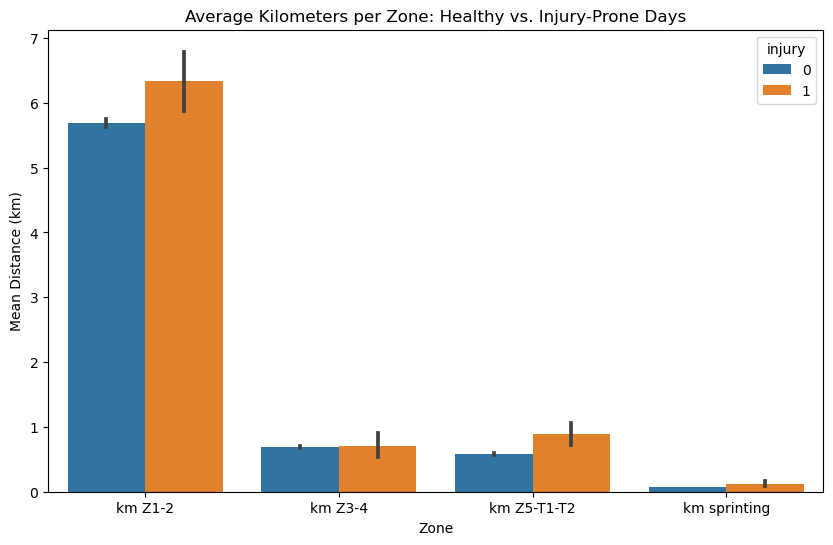

--- ANALYSIS BY INJURY STATUS ---
        high_stress_ratio  total km  km sprinting
injury                                           
0                0.104228  7.024178      0.072356
1                0.137374  8.051801      0.120755


In [7]:
# 1. Feature Engineering: Calculate Z1-2
# We assume Total KM is the sum of all intensities plus the aerobic base.
df['km Z1-2'] = df['total km'] - (df['km Z3-4'] + df['km Z5-T1-T2'] + df['km sprinting'])
df['km Z1-2'] = df['km Z1-2'].clip(lower=0)

# 2. Create an Intensity Ratio
# This ratio represents what percentage of the total training is "High Stress"
df['high_stress_ratio'] = (df['km Z3-4'] + df['km Z5-T1-T2'] + df['km sprinting']) / (df['total km'] + 1e-5)

# 3. Visualization: Intensity Profile of Injuries
# We compare the training profile of days leading to injury (1) vs healthy days (0)
zones = ['km Z1-2', 'km Z3-4', 'km Z5-T1-T2', 'km sprinting']

plt.figure(figsize=(10, 6))
df_melted = df.melt(id_vars=['injury'], value_vars=zones, var_name='Zone', value_name='KM')

sns.barplot(data=df_melted, x='Zone', y='KM', hue='injury', estimator='mean')
plt.title('Average Kilometers per Zone: Healthy vs. Injury-Prone Days')
plt.ylabel('Mean Distance (km)')
plt.show()

# 4. Statistical Summary
summary = df.groupby('injury')[['high_stress_ratio', 'total km', 'km sprinting']].mean()
print("--- ANALYSIS BY INJURY STATUS ---")
print(summary)

### **Analysis of Intensity Profiles (Medical Interpretation)**

The bar chart reveals a clear **dosage-response relationship** between training intensity and injury status. Here are the key findings:

1.  **Overload in All Zones:** Athletes in the "Injury" group (orange) show a higher average mileage across **every single intensity zone** compared to healthy days. This suggests that injuries in this dataset are primarily linked to **overall cumulative fatigue** rather than just one specific type of workout.
2.  **The Z5 and Sprinting "Risk Jump":** In **km Z5-T1-T2**, there is a very visible increase. This zone represents the anaerobic threshold. High volume here leads to metabolic fatigue and metabolic by-product accumulation, which can degrade neuromuscular control.
    * In **km sprinting**, although the absolute kilometers are low, the relative difference is huge. Sprinting involves the highest mechanical peak loads on tendons and hamstrings.
3.  **The Recovery Paradox (Z1-2):** Surprisingly, the injured group also has more km in Z1-2. 
    * *Interpretation:* This might indicate that athletes were trying to "run through the pain" by doing more easy kilometers to maintain fitness while already feeling the onset of an injury, or simply that their overall weekly volume was too high across the board.
4.  **Error Bars (Confidence Intervals):** Notice that the black lines (error bars) are much taller for the `injury=1` group. This is because we have much less data for injuries (as we saw in the class imbalance analysis), making the estimate more volatile.